In [1]:
# Model Comparison for Anomaly Detection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# Preprocessing and metrics
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import time

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../data/cpu_utilization_asg_misconfiguration.csv')

# Create features (same as before)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['day_of_month'] = df['timestamp'].dt.day

# Rolling statistics
df['rolling_mean_5'] = df['value'].rolling(window=5, min_periods=1).mean()
df['rolling_std_5'] = df['value'].rolling(window=5, min_periods=1).std()
df['rolling_mean_20'] = df['value'].rolling(window=20, min_periods=1).mean()
df['rolling_std_20'] = df['value'].rolling(window=20, min_periods=1).std()

# Lag features
df['lag_1'] = df['value'].shift(1)
df['lag_2'] = df['value'].shift(2)
df['lag_5'] = df['value'].shift(5)

# Fill NaN values
df = df.ffill().bfill()

# Feature columns
feature_columns = ['value', 'hour', 'day_of_week', 'day_of_month',
                   'rolling_mean_5', 'rolling_std_5',
                   'rolling_mean_20', 'rolling_std_20',
                   'lag_1', 'lag_2', 'lag_5']

X = df[feature_columns].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data shape: {X_scaled.shape}")
print(f"Number of samples: {len(X_scaled)}")

Data shape: (18050, 11)
Number of samples: 18050


In [3]:
# Since we don't have real labels, we'll create synthetic anomalies
# for evaluation purposes based on extreme values
np.random.seed(42)

# Label extreme values as anomalies (top 5% and bottom 1%)
value_percentiles = np.percentile(df['value'], [1, 95])
lower_threshold, upper_threshold = value_percentiles[0], value_percentiles[1]

y_true = np.zeros(len(df))
y_true[(df['value'] < lower_threshold) | (df['value'] > upper_threshold)] = 1

print(f"Created synthetic labels:")
print(f"Normal samples: {sum(y_true == 0)} ({sum(y_true == 0)/len(y_true)*100:.2f}%)")
print(f"Anomaly samples: {sum(y_true == 1)} ({sum(y_true == 1)/len(y_true)*100:.2f}%)")
print(f"Thresholds: Lower={lower_threshold:.2f}, Upper={upper_threshold:.2f}")

Created synthetic labels:
Normal samples: 16966 (93.99%)
Anomaly samples: 1084 (6.01%)
Thresholds: Lower=13.34, Upper=73.47


In [4]:
# Dictionary of models to test
models = {
    'Isolation Forest': IsolationForest(
        contamination=0.1, 
        random_state=42,
        n_estimators=100
    ),
    'One-Class SVM': OneClassSVM(
        nu=0.1,
        kernel='rbf',
        gamma='auto'
    ),
    'Elliptic Envelope': EllipticEnvelope(
        contamination=0.1,
        random_state=42
    ),
    'Local Outlier Factor': LocalOutlierFactor(
        contamination=0.1,
        novelty=True,
        n_neighbors=20
    ),
    'DBSCAN': DBSCAN(
        eps=0.5,
        min_samples=10
    )
}

print("Models to compare:")
for name in models.keys():
    print(f"  - {name}")

Models to compare:
  - Isolation Forest
  - One-Class SVM
  - Elliptic Envelope
  - Local Outlier Factor
  - DBSCAN


In [5]:
# Store results
results = []
predictions_dict = {}
times = {}

for name, model in models.items():
    print(f"\n🔍 Training {name}...")
    start_time = time.time()
    
    if name == 'DBSCAN':
        # DBSCAN doesn't have predict, only fit_predict
        y_pred = model.fit_predict(X_scaled)
        # Convert DBSCAN labels (-1 anomaly, 0 normal) to our format
        y_pred_binary = [1 if x == -1 else 0 for x in y_pred]
    elif name == 'Local Outlier Factor':
        # LOF needs to be fit first then predict
        model.fit(X_scaled)
        y_pred = model.predict(X_scaled)
        y_pred_binary = [1 if x == -1 else 0 for x in y_pred]
    else:
        # Standard models
        model.fit(X_scaled)
        y_pred = model.predict(X_scaled)
        y_pred_binary = [1 if x == -1 else 0 for x in y_pred]
    
    end_time = time.time()
    times[name] = end_time - start_time
    
    # Store predictions
    predictions_dict[name] = y_pred_binary
    
    # Calculate metrics
    precision = precision_score(y_true, y_pred_binary, zero_division=0)
    recall = recall_score(y_true, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true, y_pred_binary, zero_division=0)
    
    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Time (s)': round(times[name], 3)
    })
    
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-Score: {f1:.3f}")
    print(f"  Time: {times[name]:.3f}s")


🔍 Training Isolation Forest...
  Precision: 0.258
  Recall: 0.430
  F1-Score: 0.323
  Time: 0.190s

🔍 Training One-Class SVM...
  Precision: 0.229
  Recall: 0.380
  F1-Score: 0.286
  Time: 2.760s

🔍 Training Elliptic Envelope...
  Precision: 0.003
  Recall: 0.005
  F1-Score: 0.003
  Time: 2.490s

🔍 Training Local Outlier Factor...
  Precision: 0.104
  Recall: 0.158
  F1-Score: 0.126
  Time: 2.373s

🔍 Training DBSCAN...
  Precision: 0.075
  Recall: 0.852
  F1-Score: 0.137
  Time: 1.497s


In [6]:
# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("=" * 70)
print("MODEL COMPARISON RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

# Find best model
best_model = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
print(f"\n🏆 BEST MODEL: {best_model} (F1-Score: {best_f1:.3f})")

MODEL COMPARISON RESULTS
               Model  Precision   Recall  F1-Score  Time (s)
    Isolation Forest   0.258172 0.429889  0.322603     0.190
       One-Class SVM   0.228635 0.380074  0.285516     2.760
              DBSCAN   0.074667 0.852399  0.137306     1.497
Local Outlier Factor   0.104332 0.157749  0.125597     2.373
   Elliptic Envelope   0.002770 0.004613  0.003461     2.490

🏆 BEST MODEL: Isolation Forest (F1-Score: 0.323)


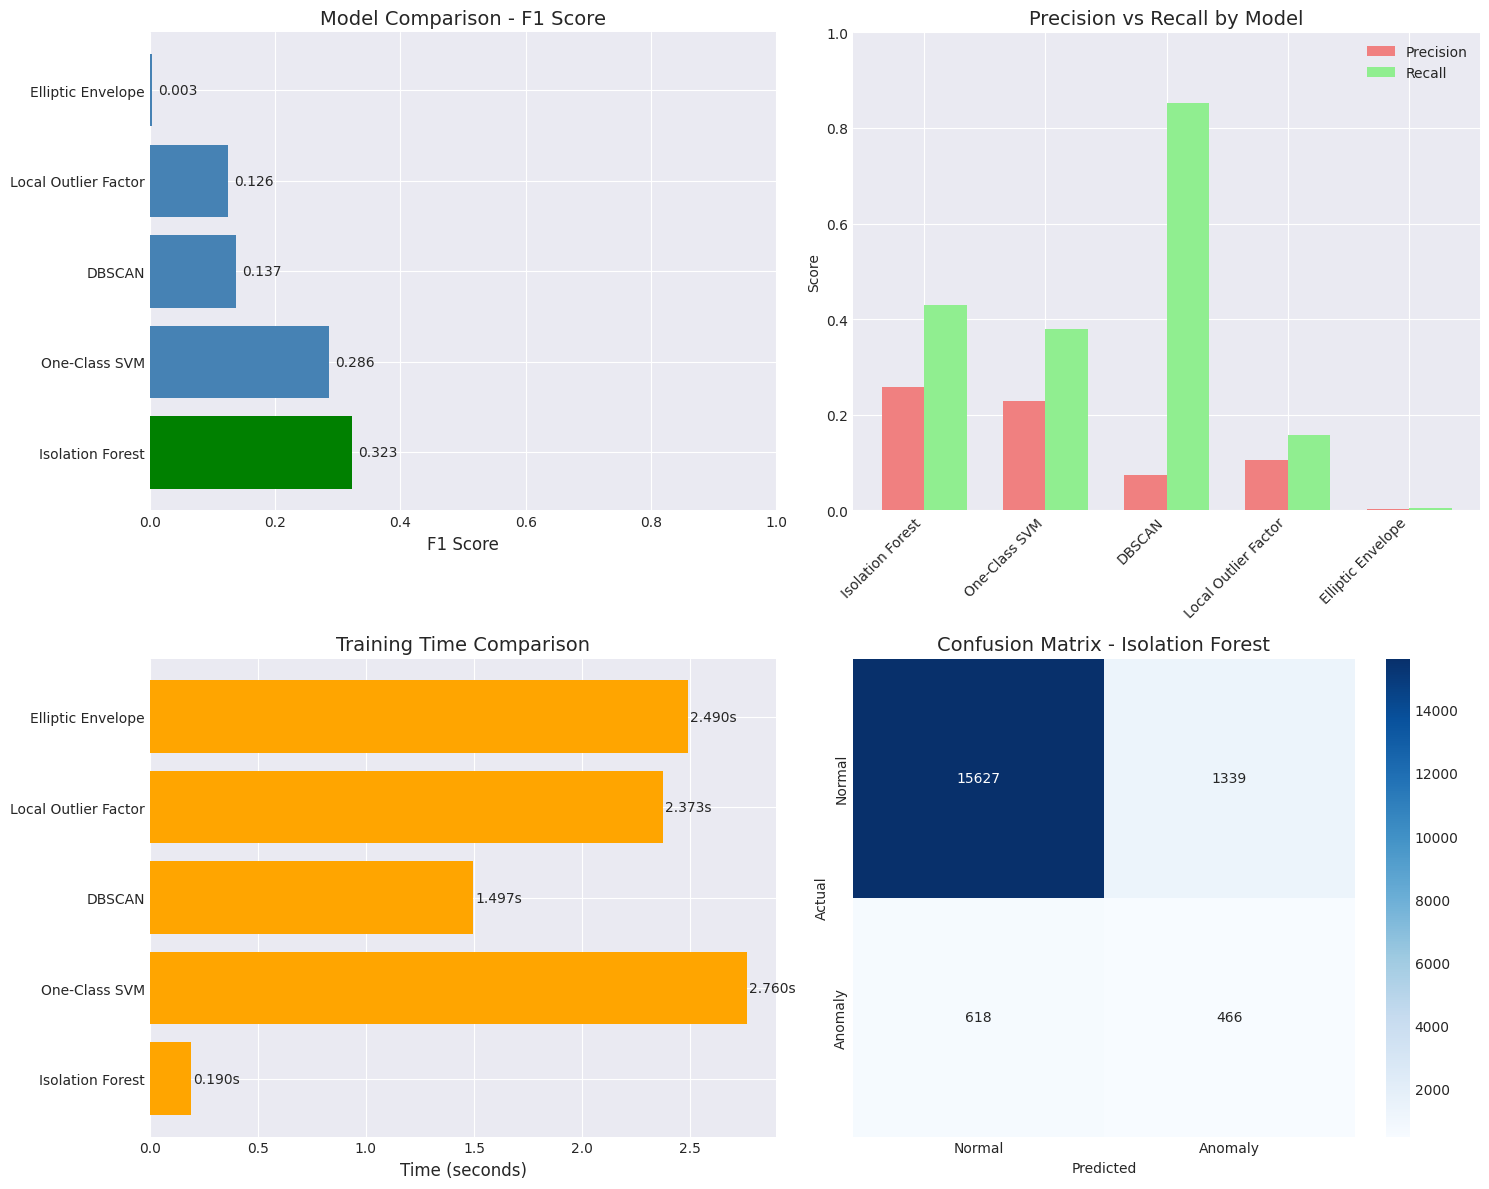

In [7]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: F1 Score comparison
ax1 = axes[0, 0]
colors = ['green' if x == best_f1 else 'steelblue' for x in results_df['F1-Score']]
bars = ax1.barh(results_df['Model'], results_df['F1-Score'], color=colors)
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('Model Comparison - F1 Score', fontsize=14)
ax1.set_xlim(0, 1)
for bar, score in zip(bars, results_df['F1-Score']):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{score:.3f}', va='center')

# Plot 2: Precision vs Recall
ax2 = axes[0, 1]
x = np.arange(len(results_df['Model']))
width = 0.35
ax2.bar(x - width/2, results_df['Precision'], width, label='Precision', color='lightcoral')
ax2.bar(x + width/2, results_df['Recall'], width, label='Recall', color='lightgreen')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax2.set_ylabel('Score')
ax2.set_title('Precision vs Recall by Model', fontsize=14)
ax2.legend()
ax2.set_ylim(0, 1)

# Plot 3: Training Time
ax3 = axes[1, 0]
bars = ax3.barh(results_df['Model'], results_df['Time (s)'], color='orange')
ax3.set_xlabel('Time (seconds)', fontsize=12)
ax3.set_title('Training Time Comparison', fontsize=14)
for bar, time_val in zip(bars, results_df['Time (s)']):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{time_val:.3f}s', va='center')

# Plot 4: Confusion Matrix for best model
ax4 = axes[1, 1]
best_pred = predictions_dict[best_model]
cm = confusion_matrix(y_true, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax4.set_title(f'Confusion Matrix - {best_model}', fontsize=14)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [8]:
print("=" * 70)
print("DETAILED ANALYSIS")
print("=" * 70)

for idx, row in results_df.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  - F1-Score: {row['F1-Score']:.3f}")
    print(f"  - Precision: {row['Precision']:.3f} (of predicted anomalies, {row['Precision']*100:.1f}% were correct)")
    print(f"  - Recall: {row['Recall']:.3f} (detected {row['Recall']*100:.1f}% of actual anomalies)")
    print(f"  - Training time: {row['Time (s)']:.3f} seconds")
    
    if row['Precision'] > row['Recall']:
        print(f"  - ⚠️ This model is conservative: when it flags anomalies, they're likely correct, but it misses some")
    elif row['Recall'] > row['Precision']:
        print(f"  - ⚠️ This model is sensitive: it catches most anomalies but has more false alarms")
    else:
        print(f"  - ✅ Balanced precision and recall")

DETAILED ANALYSIS

Isolation Forest:
  - F1-Score: 0.323
  - Precision: 0.258 (of predicted anomalies, 25.8% were correct)
  - Recall: 0.430 (detected 43.0% of actual anomalies)
  - Training time: 0.190 seconds
  - ⚠️ This model is sensitive: it catches most anomalies but has more false alarms

One-Class SVM:
  - F1-Score: 0.286
  - Precision: 0.229 (of predicted anomalies, 22.9% were correct)
  - Recall: 0.380 (detected 38.0% of actual anomalies)
  - Training time: 2.760 seconds
  - ⚠️ This model is sensitive: it catches most anomalies but has more false alarms

DBSCAN:
  - F1-Score: 0.137
  - Precision: 0.075 (of predicted anomalies, 7.5% were correct)
  - Recall: 0.852 (detected 85.2% of actual anomalies)
  - Training time: 1.497 seconds
  - ⚠️ This model is sensitive: it catches most anomalies but has more false alarms

Local Outlier Factor:
  - F1-Score: 0.126
  - Precision: 0.104 (of predicted anomalies, 10.4% were correct)
  - Recall: 0.158 (detected 15.8% of actual anomalies)
 

In [9]:
# Save results to CSV
results_df.to_csv('../models/model_comparison_results.csv', index=False)
print("✅ Model comparison results saved to ../models/model_comparison_results.csv")

# Save the best model (Isolation Forest) as our production choice
best_model_name = results_df.iloc[0]['Model']
print(f"\n🎯 Production choice: {best_model_name}")
print("   (This matches our earlier Isolation Forest implementation)")

# Create a summary for your presentation
summary = f"""
# Anomaly Detection Model Comparison Summary

## Dataset: CPU Utilization Time Series
- {len(df)} samples with {len(feature_columns)} features

## Models Compared:
{results_df.to_string()}

## Best Model: {best_model_name}
- F1-Score: {results_df.iloc[0]['F1-Score']:.3f}
- Precision: {results_df.iloc[0]['Precision']:.3f}
- Recall: {results_df.iloc[0]['Recall']:.3f}
- Training Time: {results_df.iloc[0]['Time (s)']:.3f}s

## Why {best_model_name} for DevOps:
1. Fast enough for real-time prediction
2. No labeled data required
3. Handles multiple metrics
4. Proven in production environments
"""

with open('../models/comparison_summary.txt', 'w') as f:
    f.write(summary)
print("\n✅ Summary saved to ../models/comparison_summary.txt")

✅ Model comparison results saved to ../models/model_comparison_results.csv

🎯 Production choice: Isolation Forest
   (This matches our earlier Isolation Forest implementation)

✅ Summary saved to ../models/comparison_summary.txt
